# Sales Analytics Visualization

Analysis of sales data from the `marts.fct_daily_sales` table.

**Run the pipeline first:**
```bash
bash orchestration/run_pipeline.sh
```

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import os

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [11]:
# Connect to database
# When running in Docker: use 'postgres' as host
# When running locally: use 'localhost' as host

host = 'localhost'
port = '5432'
database = 'sales_analytics'
user = 'dataeng'
password = 'changeme_strong_password'

connection_string = f'postgresql://{user}:{password}@{host}:{port}/{database}'
engine = create_engine(connection_string)

print(f"Connected to {database} at {host}:{port}")

Connected to sales_analytics at localhost:5432


In [12]:
# Load data from marts layer
query = """
SELECT 
    date,
    store_id,
    region,
    customer_type,
    transaction_count,
    total_quantity,
    gross_revenue,
    total_discount,
    net_revenue,
    avg_basket_size
FROM staging_marts.fct_daily_sales
ORDER BY date, store_id
"""

df = pd.read_sql(query, engine)
print(f"Loaded {len(df)} rows from marts.fct_daily_sales")

# Fix date parsing issues: convert to datetime and filter out invalid years
# This handles cases like '0023-01-20' that result from 2-digit year parsing
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df[df['date'].dt.year >= 2000].copy()
print(f"After filtering invalid dates: {len(df)} rows")

df.head()

Loaded 44 rows from marts.fct_daily_sales
After filtering invalid dates: 44 rows


,date,store_id,region,customer_type,transaction_count,total_quantity,gross_revenue,total_discount,net_revenue,avg_basket_size
0,2023-01-15,STORE_005,WEST,Regular,1,2,2599.98,0.0000,2599.9800,2599.9800
1,2023-01-16,STORE_005,WEST,Premium,1,1,1499.99,74.9995,1424.9905,1424.9905
2,2023-01-17,STORE_005,WEST,Regular,1,3,269.97,0.0000,269.9700,269.9700
3,2023-01-19,STORE_005,WEST,Regular,1,0,0.00,0.0000,0.0000,0.0000
4,2023-01-20,STORE_005,WEST,Regular,1,5,99.95,0.0000,99.9500,99.9500


## Chart 1: Daily Revenue Trend

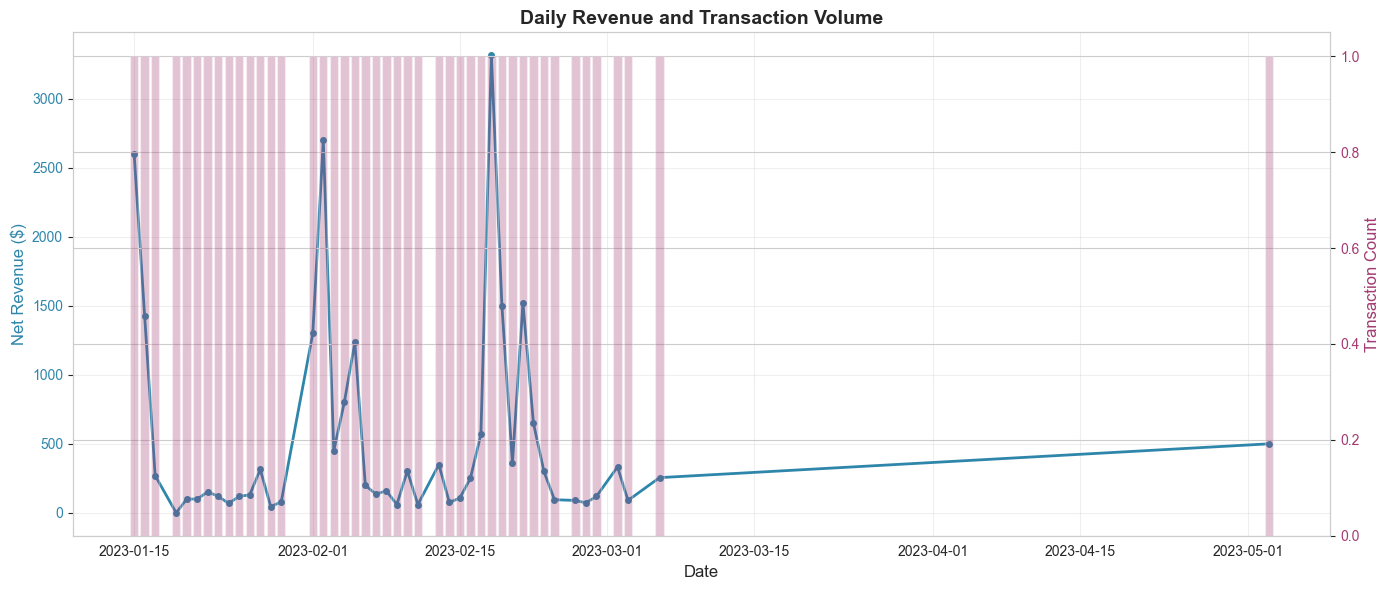

In [13]:
# Aggregate to daily level
daily_revenue = df.groupby('date').agg({
    'net_revenue': 'sum',
    'transaction_count': 'sum'
}).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 6))

# Revenue line
ax1.plot(daily_revenue['date'], daily_revenue['net_revenue'], 
         color='#2E86AB', linewidth=2, marker='o', markersize=4)
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Net Revenue ($)', color='#2E86AB', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#2E86AB')
ax1.grid(True, alpha=0.3)

# Transaction count on secondary axis
ax2 = ax1.twinx()
ax2.bar(daily_revenue['date'], daily_revenue['transaction_count'], 
        alpha=0.3, color='#A23B72', width=0.8)
ax2.set_ylabel('Transaction Count', color='#A23B72', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#A23B72')

plt.title('Daily Revenue and Transaction Volume', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Chart 2: Revenue by Store and Region

C:\Users\cedri\AppData\Local\Temp\ipykernel_35384\692231240.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=store_revenue, x='store_id', y='net_revenue',
C:\Users\cedri\AppData\Local\Temp\ipykernel_35384\692231240.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_revenue, x='region', y='net_revenue',


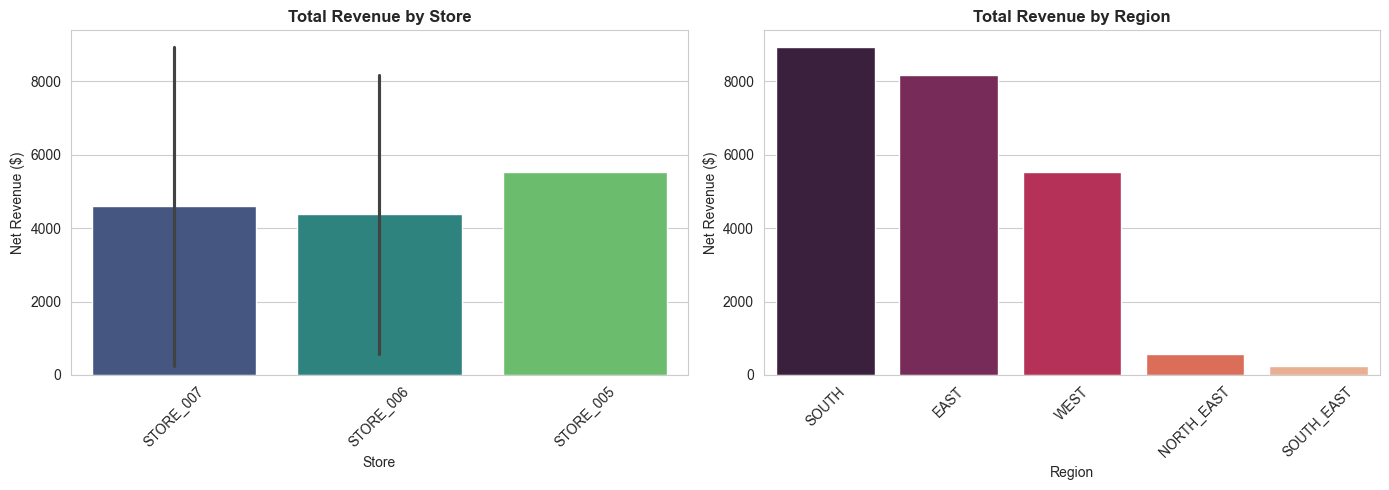

In [14]:
# Aggregate by store
store_revenue = df.groupby(['store_id', 'region']).agg({
    'net_revenue': 'sum',
    'transaction_count': 'sum'
}).reset_index().sort_values('net_revenue', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# By store
sns.barplot(data=store_revenue, x='store_id', y='net_revenue', 
            palette='viridis', ax=ax1)
ax1.set_title('Total Revenue by Store', fontsize=12, fontweight='bold')
ax1.set_xlabel('Store', fontsize=10)
ax1.set_ylabel('Net Revenue ($)', fontsize=10)
ax1.tick_params(axis='x', rotation=45)

# By region
region_revenue = df.groupby('region')['net_revenue'].sum().reset_index().sort_values('net_revenue', ascending=False)
sns.barplot(data=region_revenue, x='region', y='net_revenue', 
            palette='rocket', ax=ax2)
ax2.set_title('Total Revenue by Region', fontsize=12, fontweight='bold')
ax2.set_xlabel('Region', fontsize=10)
ax2.set_ylabel('Net Revenue ($)', fontsize=10)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Chart 3: Customer Segmentation Analysis

C:\Users\cedri\AppData\Local\Temp\ipykernel_35384\3143363937.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=customer_metrics, x='customer_type', y='avg_basket_size',


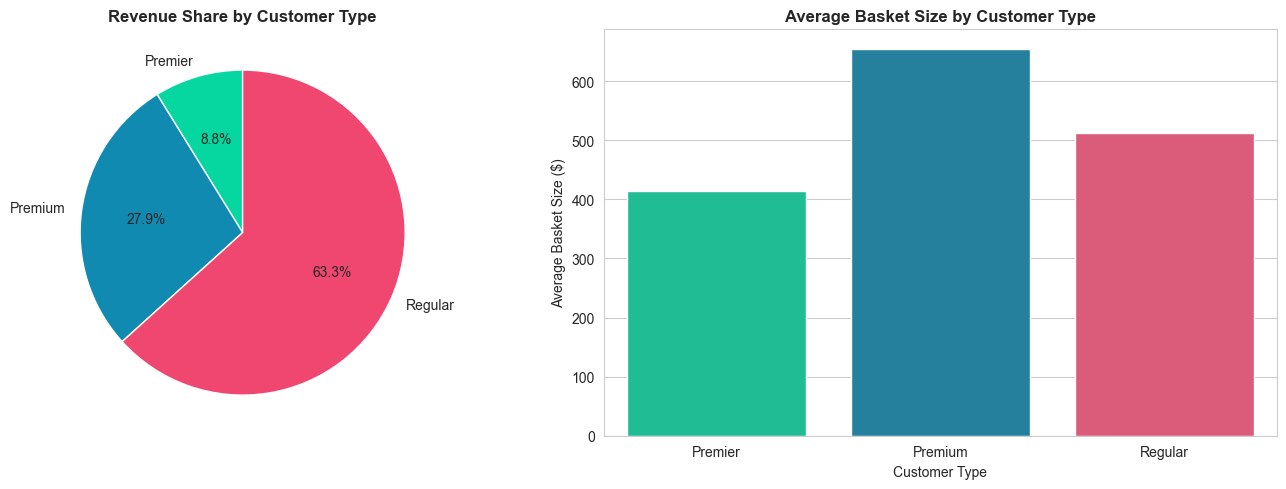


Customer Type Metrics:
customer_type  transaction_count  net_revenue  avg_basket_size
      Premier                  5    2071.8985       414.379700
      Premium                 10    6546.8685       654.686850
      Regular                 29   14861.5980       512.468897


In [15]:
# Aggregate by customer type
customer_metrics = df.groupby('customer_type').agg({
    'net_revenue': 'sum',
    'transaction_count': 'sum',
    'avg_basket_size': 'mean'
}).reset_index()

# Calculate percentage of total revenue
customer_metrics['revenue_pct'] = (customer_metrics['net_revenue'] / customer_metrics['net_revenue'].sum()) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Revenue by customer type (pie chart)
colors = ['#06D6A0', '#118AB2', '#EF476F']
ax1.pie(customer_metrics['net_revenue'], labels=customer_metrics['customer_type'],
        autopct='%1.1f%%', colors=colors, startangle=90)
ax1.set_title('Revenue Share by Customer Type', fontsize=12, fontweight='bold')

# Average basket size by customer type
sns.barplot(data=customer_metrics, x='customer_type', y='avg_basket_size',
            palette=colors, ax=ax2)
ax2.set_title('Average Basket Size by Customer Type', fontsize=12, fontweight='bold')
ax2.set_xlabel('Customer Type', fontsize=10)
ax2.set_ylabel('Average Basket Size ($)', fontsize=10)

plt.tight_layout()
plt.show()

print("\nCustomer Type Metrics:")
print(customer_metrics[['customer_type', 'transaction_count', 'net_revenue', 'avg_basket_size']].to_string(index=False))

## Chart 4: Discount Impact Analysis

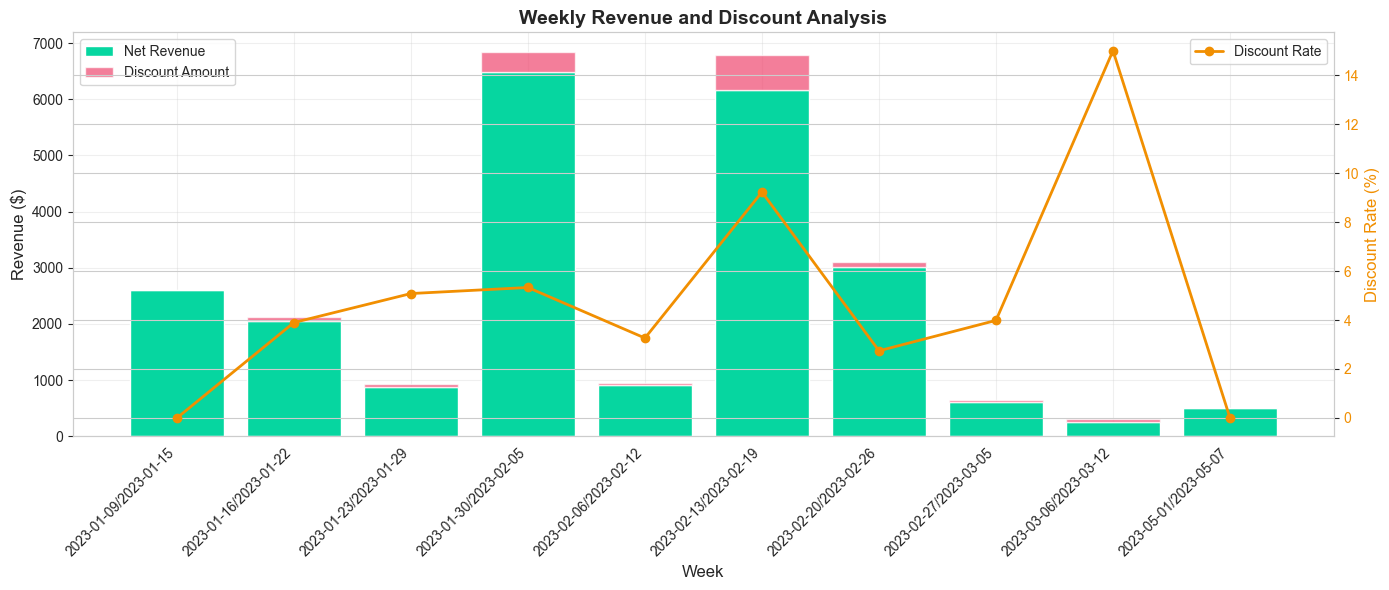


Overall discount rate: 5.28%
Total revenue impact: $1308.47


In [16]:
# Calculate discount rate and impact
df['discount_rate'] = df['total_discount'] / df['gross_revenue']
df['discount_rate_pct'] = df['discount_rate'] * 100

# Weekly aggregation (date is already datetime from earlier conversion)
df['week'] = df['date'].dt.to_period('W').astype(str)
weekly_discount = df.groupby('week').agg({
    'gross_revenue': 'sum',
    'total_discount': 'sum',
    'net_revenue': 'sum'
}).reset_index()
weekly_discount['discount_rate'] = (weekly_discount['total_discount'] / weekly_discount['gross_revenue']) * 100

fig, ax1 = plt.subplots(figsize=(14, 6))

# Stacked bar: gross vs discount
x_pos = range(len(weekly_discount))
ax1.bar(x_pos, weekly_discount['net_revenue'], label='Net Revenue', color='#06D6A0')
ax1.bar(x_pos, weekly_discount['total_discount'], bottom=weekly_discount['net_revenue'],
        label='Discount Amount', color='#EF476F', alpha=0.7)

ax1.set_xlabel('Week', fontsize=12)
ax1.set_ylabel('Revenue ($)', fontsize=12)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(weekly_discount['week'], rotation=45, ha='right')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Discount rate line on secondary axis
ax2 = ax1.twinx()
ax2.plot(x_pos, weekly_discount['discount_rate'], color='#F18F01', 
         marker='o', linewidth=2, markersize=6, label='Discount Rate')
ax2.set_ylabel('Discount Rate (%)', color='#F18F01', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#F18F01')
ax2.legend(loc='upper right')

plt.title('Weekly Revenue and Discount Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nOverall discount rate: {(df['total_discount'].sum() / df['gross_revenue'].sum() * 100):.2f}%")
print(f"Total revenue impact: ${df['total_discount'].sum():.2f}")

## Summary Statistics

In [17]:
print("=" * 60)
print("SALES ANALYTICS SUMMARY")
print("=" * 60)
print(f"\nDate Range: {df['date'].min()} to {df['date'].max()}")
print(f"Total Transactions: {df['transaction_count'].sum():,.0f}")
print(f"Total Items Sold: {df['total_quantity'].sum():,.0f}")
print(f"\nRevenue Metrics:")
print(f"  Gross Revenue: ${df['gross_revenue'].sum():,.2f}")
print(f"  Total Discounts: ${df['total_discount'].sum():,.2f}")
print(f"  Net Revenue: ${df['net_revenue'].sum():,.2f}")
print(f"  Average Basket Size: ${df['avg_basket_size'].mean():,.2f}")
print(f"\nTop Performing Store: {store_revenue.iloc[0]['store_id']} (${store_revenue.iloc[0]['net_revenue']:,.2f})")
print(f"Top Performing Region: {region_revenue.iloc[0]['region']} (${region_revenue.iloc[0]['net_revenue']:,.2f})")
print("=" * 60)

SALES ANALYTICS SUMMARY

Date Range: 2023-01-15 00:00:00 to 2023-05-03 00:00:00
Total Transactions: 44
Total Items Sold: 116

Revenue Metrics:
  Gross Revenue: $24,788.84
  Total Discounts: $1,308.47
  Net Revenue: $23,480.36
  Average Basket Size: $533.64

Top Performing Store: STORE_007 ($8,944.08)
Top Performing Region: SOUTH ($8,944.08)
